In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.DEBUG, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import sdata
import uuid
import time


Autosave disabled


10:56:43 DEBUG:Loaded backend module://ipykernel.pylab.backend_inline version unknown.


sdata v0.17.0


In [2]:
vaultrootpath = "/tmp/sdatavaultgraphclass"
import shutil
shutil.rmtree(vaultrootpath, ignore_errors=True)

In [3]:
vault = FileSystemVault(vaultrootpath)
vault.index.df

10:56:43 INFO:create/open vault /tmp/sdatavaultgraphclass


,!sdata_version,!sdata_name,!sdata_uuid,!sdata_class,!sdata_parent,!sdata_project,!sdata_ctime,!sdata_mtime


In [4]:
vault

(FileSystemVault:/tmp/sdatavaultgraphclass)

In [5]:
data = sdata.Data(name="otto", 
                  uuid=sdata.uuid_from_str("otto"), 
                  table=pd.DataFrame({"a":[1,2,3]}),
                  description="Hallo\nSpencer",
                  project="P1")
data.metadata.add("a", 1)
datac = data.copy()
datac.uuid = '2689e23926874382b10b95e0f1cd90eb'
data2 = sdata.Data(name="karl", 
                   uuid=sdata.uuid_from_str("karl"))
data, datac, data2

((Data 'otto':21b83703d98e38a7be2e50e38326d0ce),
 (Data 'otto':2689e23926874382b10b95e0f1cd90eb),
 (Data 'karl':df26fe1945b93a149ee710e8fa887b2e))

In [6]:
vault.dump_blob(data)
vault.dump_blob(data2)
vault.dump_blob(datac)

10:56:43 INFO:dump blob /tmp/sdatavaultgraphclass/objects/21/ce/
10:56:43 INFO:NumExpr defaulting to 8 threads.
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/ipykernel_launcher.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['name', 'value', 'dtype', 'unit', 'description', 'label'], dtype='object')]

  """Entry point for launching an IPython kernel.
10:56:44 INFO:dump blob /tmp/sdatavaultgraphclass/objects/df/2e/
10:56:44 INFO:dump blob /tmp/sdatavaultgraphclass/objects/26/eb/
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/ipykernel_launcher.py:3: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed-integer,key->block0_values] [items->Index(['name', 'value', 'dtype', 'unit', 'description', 'label'], 

In [7]:
vault.dump_hdf5_index()
vault.index.df

,!sdata_version,!sdata_name,!sdata_uuid,!sdata_class,!sdata_parent,!sdata_project,!sdata_ctime,!sdata_mtime
21b83703d98e38a7be2e50e38326d0ce,0.17.0,otto,21b83703d98e38a7be2e50e38326d0ce,Data,,P1,2021-01-18T10:56:43.790753+00:00,2021-01-18T10:56:43.790871+00:00
df26fe1945b93a149ee710e8fa887b2e,0.17.0,karl,df26fe1945b93a149ee710e8fa887b2e,Data,,,2021-01-18T10:56:43.792112+00:00,2021-01-18T10:56:43.792180+00:00
2689e23926874382b10b95e0f1cd90eb,0.17.0,otto,2689e23926874382b10b95e0f1cd90eb,Data,21b83703d98e38a7be2e50e38326d0ce,P1,2021-01-18T10:56:43.790753+00:00,2021-01-18T10:56:43.791758+00:00


In [8]:
d = {}
for dat in [data, data2, datac]:
    d[dat.uuid] = dat.metadata.to_dict()
d.keys()

dict_keys(['21b83703d98e38a7be2e50e38326d0ce', 'df26fe1945b93a149ee710e8fa887b2e', '2689e23926874382b10b95e0f1cd90eb'])

In [9]:
vault.index.df.to_dict(orient="index")

{'21b83703d98e38a7be2e50e38326d0ce': {'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00'},
 'df26fe1945b93a149ee710e8fa887b2e': {'!sdata_version': '0.17.0',
  '!sdata_name': 'karl',
  '!sdata_uuid': 'df26fe1945b93a149ee710e8fa887b2e',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': '',
  '!sdata_ctime': '2021-01-18T10:56:43.792112+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.792180+00:00'},
 '2689e23926874382b10b95e0f1cd90eb': {'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb',
  '!sdata_class': 'Data',
  '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.79

In [10]:
for identifier, datadict in vault.index.df.to_dict(orient="index").items():
    print(identifier, datadict)

21b83703d98e38a7be2e50e38326d0ce {'!sdata_version': '0.17.0', '!sdata_name': 'otto', '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce', '!sdata_class': 'Data', '!sdata_parent': '', '!sdata_project': 'P1', '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00', '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00'}
df26fe1945b93a149ee710e8fa887b2e {'!sdata_version': '0.17.0', '!sdata_name': 'karl', '!sdata_uuid': 'df26fe1945b93a149ee710e8fa887b2e', '!sdata_class': 'Data', '!sdata_parent': '', '!sdata_project': '', '!sdata_ctime': '2021-01-18T10:56:43.792112+00:00', '!sdata_mtime': '2021-01-18T10:56:43.792180+00:00'}
2689e23926874382b10b95e0f1cd90eb {'!sdata_version': '0.17.0', '!sdata_name': 'otto', '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb', '!sdata_class': 'Data', '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce', '!sdata_project': 'P1', '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00', '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00'}


In [11]:
vaultrootpath

'/tmp/sdatavaultgraphclass'

In [46]:
db_file = os.path.join(vaultrootpath, "sdatavaultsimpegraph.sqlite")
db_file

'/tmp/sdatavaultgraphclass/sdatavaultsimpegraph.sqlite'

In [13]:
if os.path.exists(db_name):
    os.remove(db_name)

In [14]:
from sdata.contrib.simple_graph import database as db
db.initialize(db_name)

In [15]:
# for uuidhex, datadict in vault.index.df.to_dict(orient="index").items():
# #    identifier = db.uuidstr2uuidint(uuidhex)
#     identifier = uuidhex
#     print(uuidhex, identifier)
#     db.atomic(db_name, db.add_node(datadict, identifier))


In [16]:
for uuidhex, datadict in vault.index.df.to_dict(orient="index").items():
#    identifier = db.uuidstr2uuidint(uuidhex)
    identifier = uuidhex
    print(uuidhex, identifier)
    db.atomic(db_name, db.upsert_node(identifier, datadict))



21b83703d98e38a7be2e50e38326d0ce 21b83703d98e38a7be2e50e38326d0ce
df26fe1945b93a149ee710e8fa887b2e df26fe1945b93a149ee710e8fa887b2e
2689e23926874382b10b95e0f1cd90eb 2689e23926874382b10b95e0f1cd90eb


In [17]:
db.visualize(db_name, '{}.dot'.format(db_name), ['2689e23926874382b10b95e0f1cd90eb', '21b83703d98e38a7be2e50e38326d0ce', 'df26fe1945b93a149ee710e8fa887b2e'])

os.system("dot -Tpng {0}.dot -o {0}.png".format(db_name))

0

In [18]:
#db.atomic(db_name, db.find_node(51226596861945717314284025759969153259))
identifier = '2689e23926874382b10b95e0f1cd90eb'
db.atomic(db_name, db.find_node(identifier))

{'!sdata_version': '0.17.0',
 '!sdata_name': 'otto',
 '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb',
 '!sdata_class': 'Data',
 '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce',
 '!sdata_project': 'P1',
 '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
 '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00',
 'id': '2689e23926874382b10b95e0f1cd90eb'}

In [19]:
uuidhex = '21b83703d98e38a7be2e50e38326d0ce'
# db.atomic(db_name, db.find_node(db.uuidstr2uuidint(uuidhex)))
db.atomic(db_name, db.find_node(uuidhex))

{'!sdata_version': '0.17.0',
 '!sdata_name': 'otto',
 '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce',
 '!sdata_class': 'Data',
 '!sdata_parent': '',
 '!sdata_project': 'P1',
 '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
 '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00',
 'id': '21b83703d98e38a7be2e50e38326d0ce'}

In [20]:
db.atomic(db_name, db.find_nodes({'!sdata_name': 'karl'}, db._search_like, db._search_starts_with))

[{'!sdata_version': '0.17.0',
  '!sdata_name': 'karl',
  '!sdata_uuid': 'df26fe1945b93a149ee710e8fa887b2e',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': '',
  '!sdata_ctime': '2021-01-18T10:56:43.792112+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.792180+00:00',
  'id': 'df26fe1945b93a149ee710e8fa887b2e'}]

In [21]:
db.atomic(db_name, db.find_nodes({'!sdata_name': 'otto'}, db._search_like, db._search_starts_with))

[{'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00',
  'id': '21b83703d98e38a7be2e50e38326d0ce'},
 {'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb',
  '!sdata_class': 'Data',
  '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00',
  'id': '2689e23926874382b10b95e0f1cd90eb'}]

In [22]:
db.atomic(db_name, db.find_nodes({'!sdata_name': ''}, db._search_like, db._search_starts_with))

[{'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00',
  'id': '21b83703d98e38a7be2e50e38326d0ce'},
 {'!sdata_version': '0.17.0',
  '!sdata_name': 'karl',
  '!sdata_uuid': 'df26fe1945b93a149ee710e8fa887b2e',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': '',
  '!sdata_ctime': '2021-01-18T10:56:43.792112+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.792180+00:00',
  'id': 'df26fe1945b93a149ee710e8fa887b2e'},
 {'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb',
  '!sdata_class': 'Data',
  '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00',
  'id':

In [23]:
db.atomic(db_name, db.find_nodes({'!sdata_project': 'P1'}, db._search_like, db._search_starts_with))

[{'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00',
  'id': '21b83703d98e38a7be2e50e38326d0ce'},
 {'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb',
  '!sdata_class': 'Data',
  '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00',
  'id': '2689e23926874382b10b95e0f1cd90eb'}]

In [24]:
for uuidhex, datadict in vault.index.df.to_dict(orient="index").items():
#     identifier = db.uuidstr2uuidint(uuidhex)
    uuidparent = datadict.get('!sdata_parent')
    if uuidparent:
        print(uuidhex, uuidparent)
        identifier = '"{}"'.format(uuidhex)
        parent_identifier = '"{}"'.format(uuidparent)
#         parent_identifier = db.uuidstr2uuidint(parent)
#         print(parent_identifier, identifier)
#        db.atomic(db_name, db.connect_nodes(parent_identifier, identifier, {}))
        db.atomic(db_name, db.connect_nodes(uuidparent, uuidhex, {'action': 'founded'}))


2689e23926874382b10b95e0f1cd90eb 21b83703d98e38a7be2e50e38326d0ce


In [25]:
db.traverse(db_name, 1, neighbors_fn=db.find_inbound_neighbors)

[]

In [26]:
import json
json.loads('"21b83703d98e38a7be2e50e38326d0ce"')

'21b83703d98e38a7be2e50e38326d0ce'

In [27]:
db.traverse(db_name, '2689e23926874382b10b95e0f1cd90eb', neighbors_fn=db.find_inbound_neighbors)

['2689e23926874382b10b95e0f1cd90eb', '21b83703d98e38a7be2e50e38326d0ce']

In [28]:
db.traverse(db_name, '21b83703d98e38a7be2e50e38326d0ce', neighbors_fn=db.find_inbound_neighbors)

['21b83703d98e38a7be2e50e38326d0ce']

In [29]:
db.traverse(db_name, '21b83703d98e38a7be2e50e38326d0ce', neighbors_fn=db.find_outbound_neighbors)

['21b83703d98e38a7be2e50e38326d0ce', '2689e23926874382b10b95e0f1cd90eb']

In [30]:
db.traverse(db_name, '2689e23926874382b10b95e0f1cd90eb', neighbors_fn=db.find_outbound_neighbors)

['2689e23926874382b10b95e0f1cd90eb']

In [31]:
db.traverse(db_name, '2689e23926874382b10b95e0f1cd90eb', neighbors_fn=db.find_neighbors)

['2689e23926874382b10b95e0f1cd90eb', '21b83703d98e38a7be2e50e38326d0ce']

In [64]:
db.visualize(db_name, '{}.dot'.format(db_name), ['2689e23926874382b10b95e0f1cd90eb', '21b83703d98e38a7be2e50e38326d0ce', 'df26fe1945b93a149ee710e8fa887b2e'])

os.system("dot -Tpng {0}.dot -o {0}.png".format(db_name))


!!node {'!sdata_version': '0.17.0', '!sdata_name': 'otto', '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb', '!sdata_class': 'Data', '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce', '!sdata_project': 'P1', '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00', '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00', 'id': '2689e23926874382b10b95e0f1cd90eb'}
!!node {'!sdata_version': '0.17.0', '!sdata_name': 'otto', '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce', '!sdata_class': 'Data', '!sdata_parent': '', '!sdata_project': 'P1', '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00', '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00', 'id': '21b83703d98e38a7be2e50e38326d0ce'}
!!node {'!sdata_version': '0.17.0', '!sdata_name': 'karl', '!sdata_uuid': 'df26fe1945b93a149ee710e8fa887b2e', '!sdata_class': 'Data', '!sdata_parent': '', '!sdata_project': '', '!sdata_ctime': '2021-01-18T10:56:43.792112+00:00', '!sdata_mtime': '2021-01-18T10:56:43.792180+00:00', 'id': 'df26fe1945b93a149ee710e8fa887b

0

In [33]:
pwd


'/home/ingolf.lepenies/projects/sdata/ipynb'

In [34]:
import pygraphviz as pgv

In [35]:
import pygraphviz as pgv

A = pgv.AGraph()

A.add_edge(1, 2)
A.add_edge(2, 3)
A.add_edge(1, 3)

print(A.string())  # print to screen
A.write("simple.dot")  # write to simple.dot

B = pgv.AGraph("simple.dot")  # create a new graph from file
B.layout()  # layout with default (neato)
B.draw("simple.png")  # draw png

strict graph "" {
	1 -- 2;
	1 -- 3;
	2 -- 3;
}



In [36]:
pwd


'/home/ingolf.lepenies/projects/sdata/ipynb'

![]("simple.png")


# halle
![simple.png](simple.png)

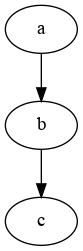

In [40]:
import pygraphviz as pgv
from IPython.display import Image

def draw(dot):
    return Image(pgv.AGraph(dot).draw(format='png', prog='dot'))

g1 = """digraph top {
   a -> b -> c;
}"""
draw(g1)

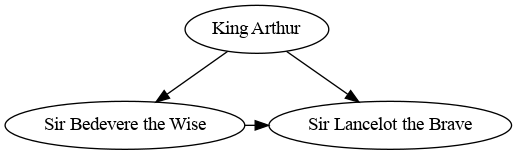

In [41]:
g2="""digraph {
    A [label="King Arthur"]
    B [label="Sir Bedevere the Wise"]
    L [label="Sir Lancelot the Brave"]
    A -> B
    A -> L
    B -> L [constraint=false]
}"""
draw(g2)

In [49]:
path = ['2689e23926874382b10b95e0f1cd90eb', '21b83703d98e38a7be2e50e38326d0ce', 'df26fe1945b93a149ee710e8fa887b2e']
[db.atomic(db_file, db.find_node(i)) for i in path]

[{'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '2689e23926874382b10b95e0f1cd90eb',
  '!sdata_class': 'Data',
  '!sdata_parent': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.791758+00:00',
  'id': '2689e23926874382b10b95e0f1cd90eb'},
 {'!sdata_version': '0.17.0',
  '!sdata_name': 'otto',
  '!sdata_uuid': '21b83703d98e38a7be2e50e38326d0ce',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': 'P1',
  '!sdata_ctime': '2021-01-18T10:56:43.790753+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.790871+00:00',
  'id': '21b83703d98e38a7be2e50e38326d0ce'},
 {'!sdata_version': '0.17.0',
  '!sdata_name': 'karl',
  '!sdata_uuid': 'df26fe1945b93a149ee710e8fa887b2e',
  '!sdata_class': 'Data',
  '!sdata_parent': '',
  '!sdata_project': '',
  '!sdata_ctime': '2021-01-18T10:56:43.792112+00:00',
  '!sdata_mtime': '2021-01-18T10:56:43.792180+00:00',
  'id':

In [52]:
for src, tgt in db.pairwise(path):
    print(src, tgt)

2689e23926874382b10b95e0f1cd90eb 21b83703d98e38a7be2e50e38326d0ce
21b83703d98e38a7be2e50e38326d0ce df26fe1945b93a149ee710e8fa887b2e


In [70]:
g = db.get_dot(db_name, path=['2689e23926874382b10b95e0f1cd90eb', '21b83703d98e38a7be2e50e38326d0ce', 'df26fe1945b93a149ee710e8fa887b2e'])
draw(g)

In [ ]:
draw(g2)